In [35]:
import pandas as pd
import numpy as np

from src.preprocess.model import StorageStaticParams, InputData



### Capacity Aging Linear Approximation

The capacity in energy storage decrease over time. It decreases with aging, but also decreases with each performed cycle. What I want to do is to approximate this phenomena by a model, that can be injected into MILP optimization formulation.

Goal is to find formula for $cap_t$ - how the capacity of a storage change in time.

The idea is simple, for a given timestamp, I need to compute the $\Delta cap_t = cap_{t+1} - cap_t$. We can decompose it into $\Delta cap_t = \Delta cap_{age, t} + \Delta cap_{cycle, t}$ (those effects are independent; if both will happen in the same time - batter will die much faster).

#### Cycle degradation
A cycle degradation is much harder topic, since each cycle decrease the capacity differently, cycles that are deeper decrease it more. Also, cycles at the beginning of the life of the storage, decrease it more, than the same cycles at the later stages.
In general, the cycle degradation depends on $dod$ (depth of discharge) of a cycle, and time in which the cycle was performed.

It is known, that the $\Delta cap_{cycle, t}$ is proportional to $(DOD_t)^{\gamma}$, where $\gamma\in[1.1, 1.3]$ (more or less). So the problem is, that it is not a linear function.

To formulate the model for a storage capacity cycle degradation, we need first to assume some level of capacity degradation at which we will decide, that the storage will stop operate. Let's call it $cap_{EOL}$ (end-of-life capacity).
Usually it is assumed to be around $80\%$ of the initial storage capacity.

Then we can assume, that the total energy throughput (in the storage lifetime) can be approximated as $T_{EOL} = margin\cdot DOD_{avg} \cdot N\cdot \frac{cap_{t_0} + cap_{EOL}}{2}$, where $N$ is the total number of cycles that storage can perform, $DOD_{avg}$ is the average
depth of storage cycle (I would assume $=0.7$, around the "sweet spot", not "maximal depth" as it causes less damage in terms of capacity degradation), $margin$ is a buffer for non-ideal conditions.

This is an approximation and assumes linear degradation (which is not true, but this is the first version, so it is acceptable at this point).

Let's define a coefficient $\alpha = \frac{\Delta cap_{cycle, total}}{T_{EOL}}$ - the ratio of total cycle capacity degradation divided by total energy throughput. This tells us, what amount of capacity (approximately) will be lost from a one unit of energy throughput.

Now, we can start by introducing some segmentation of the $[0,1]$ interval - creating capacity ranges. Let $s_i$ will be a vector of numbers from $[0,1]$, where $s_j < s_{j+1}$ and (why - it will be clear in a moment) for each $j$ we have that $P\cdot dt < cap_t\cdot (s_j - s_{j-1})$.
In other words, that ($dt$ is the time resolution, for example $0.25$ for $15$-minutes resolution) storage can not go from $soc_t = cap_t\cdot s_j$ to $soc_{t+1} > cap_t\cdot s_{j+1}$ in one timestep. We also postulate, that $s_0 = 0$ and $s_1 = 1$..

Now, let's decompose (for each $t$) $soc_t = \sum_j soc_{t,j}$ (the $j$ index is the same as for $s_j$). Next
$$
soc_{t,j} \le (s_{j+1} - s_j)\cdot cap_t
$$
$$
e_{t,j} = \sum_{j=0}^k soc_{t,j}
$$
$$
e_{j,t} \le e_{t, j+1}
$$

in that way we are sure, that if $soc_{t,j} > 0$, then all $soc_{t,l}$ are at the maximum level for all $l<j$. This will be very important property for us later.

Now, we need to define the delta state-of-charge as $\Delta soc_{t,j} \ge 0$ and $\Delta soc_{t, j} \ge soc_{t+1,j} - soc_{t,j}$.

The function $F(x) = x^{1.2}$ is non-linear, so we need to approximate the $F(DOD)\cdot soc_{max}$. We can visualize a cycle as "path upward" on the $soc(t)$ graph (where $soc(t)$ is a continuous function). When we reach the
top (the local maximum), we are on the "top" of a cycle. So the idea is this.

Let's define the following $w_j = F(s_j) - F(s_{j-1})$. The cycle degradation formula is this:

$$
\Delta cap_{cycle, t} = \alpha\cdot \sum_j w_j\cdot\Delta soc_{t,j}.
$$

Now, let's say we want to compute a degradation for a cycle, for which $soc_{max} = 0.6\cdot cap$. We can see, that no matter what path will lead us to the given $soc_{max}$, the final degradation equals $\alpha\cdot soc_{max}\cdot F(s_j)$, where $s_j$ is the end-point of the capacity
range in which $soc_{max}$ lies. This approach is much better than the industry standard used in the energy storage system models in the context of energy markets (models I find in the literature).

For most accurate approximation model, we will choose for all $j$ that $s_j - s_{j-1} = (dt + \epsilon)\cdot\frac{P}{cap}$. In that way we will enforce, that storage can not go from $soc_t = cap_t\cdot s_j$ to $soc_{t+1} > cap_t\cdot s_{j+1}$ in one timestep, and the number of
the approximation nodes will be maximal.


#### Aging degradation

Formula taken from the literature:

$$
\Delta cap_{cal, t} = f(T)_t\cdot f(SOC)_t\cdot DECAY_t,
$$

temperature component:
$$
f(T)_t = \exp\left(\frac{E_a}{R}\cdot (\frac{1}{T_{ref}} - \frac{1}{T_{amb, t} + \Delta T_{int}}) \right),
$$
where:
- $T_{ref}$ - reference temperature [K] ($298.15$ K or $~25^{\circ}C$) -- in Kelvin
- $T_{amb, t}$ - air temperature -- in Kelvin
- $\Delta T_{init}$ - constant offset representing the fact, that the internal heat BESS containers are warmer than outside air ($2-5$K) -- in Kelvin
- $R = 8.314$ (universal gas constant)
- $E_a$ - activation energy (I can assume the benchmark $=50000$) -- in $\frac{J}{mol}$

SOC component:
$$
f(SOC) = \exp(0.6\cdot SOC)
$$

time decay component:
$$
DECAY_t = \frac{B_{ref}}{2\sqrt{t}}
$$
where:
- $Q_{loss}(t) = B_{reff}\cdot \sqrt{t}$ ($t$ represent days - it is good enough approximation for my baseline 10-year model)
- it means, that $\frac{cap_{init}}{cap_{eol}}= B_{ref}\cdot\sqrt{N_{steps}}$ ($N_{steps}$ is the total number of timesteps in the storage lifetime), so $B_{ref} = \frac{cap_{init}}{cap_{eol}\cdot\sqrt{N_{steps}}}$

How to include it into the model? $f(T)_t$ can be a precomputed time series, as well as $DECAY_t$. $f(SOC)_t$ needs linear approximation - technique will be the same as the one described below for the cycle degradation modeling.


##### Improvenemnts

- try to set $\alpha = \alpha_t$, so the cycle penalization will depend on the exploitation level of the battery ($\alpha_t$ should be monotonic, and it should satisfy $\sum_t \alpha_t\cdot T_t = \sum_t \Delta cap_{cycle, t}$) - it requires time to go deep into the BESS theory
- better model of the calendar degradation; now it is extra stupid
- include air temperature to the model: degradation is different for different air temperature

probably then it will be as good as possible (it is better than most market storage models already...)

In [36]:
import os
from pathlib import Path
from src.preprocess.load import load_storage_static_params

ROOT = Path(os.getcwd()).parent
storage_static_params_path = ROOT / 'assets' / 'input' / 'storage_static_params.yaml'

storage_static_params = load_storage_static_params(storage_static_params_path)

#### Calendar degradation model

In [53]:
class CalendarDegradationModel:

    _R = 8.314  # universal gas constant [J/mol]
    _T_ref = 298.15  # reference temperature [K]
    _dT_init = 3.5  # constant offset (bess is warmer than the outside temp) [K] - it should depend on the storage power(t); future improvement
    _E_a = 5 * 1e4  # activation energy [J/mol]
    
    _SOC_DEG_RATE = 0.6
    
    def __init__(self, input_data: InputData) -> None:
        dt = input_data.market_data.resolution
        self.base_ref = self._compute_base_ref(input_data.storage_static_params, dt)
    
    def degradation(self, temperature: float, soc: float, nth_day: float) -> float:
        temperature_deg = self._temperature_degradation(temperature)
        soc_deg = self._soc_degradation(soc)
        time_deg = self._time_decay_degradation(nth_day)
        
        return  temperature_deg * soc_deg * time_deg
    
    @staticmethod
    def _compute_base_ref(sp: StorageStaticParams, dt: float) -> float:
        """
        Base reference degradation_model rate for time decay (per timestep)
        """
        cal_deg_time = sp.degradation.time_decay_duration_years  # calendar decay time
        max_cap_loss = sp.degradation.max_capacity_loss  # end of life capacity

        return max_cap_loss / (np.sqrt(cal_deg_time * 365 * 24 / dt))
        
    
    def _temperature_degradation(self, temperature: float) -> float:
        """
        Temperature degradation_model component
        """
        return np.exp(
            (self._E_a / self._R) * (1 / self._T_ref - 1 / (temperature + self._dT_init))
        )
    
    def _soc_degradation(self, soc: float) -> float:
        """
        State of charge degradation_model component
        """
        return np.exp(self._SOC_DEG_RATE * soc)
    
    def _time_decay_degradation(self, nth_timestep: float) -> float:
        """
        Time decay component
        """
        return self.base_ref / (2 * np.sqrt(nth_timestep))

#### Cycle degradation model

In [52]:
from dataclasses import dataclass
import rainflow


@dataclass
class CycleParameters:
    dod: float
    soc_avg: float
    count: float
    start_idx: int
    end_idx: int


class CycleDegradationModel:

    _R = 8.314  # [J/mol/K]
    _E_a = 5e4  # [J/mol]
    _T_ref = 298.15

    def __init__(
        self,
        input_data,
        cycle_severity_exponent: float = 1.3,
    ) -> None:
        self._a = self._compute_a(input_data, cycle_severity_exponent)
        self._cycle_severity_exponent = cycle_severity_exponent

        self._q_init = input_data.storage_static_params.technical.capacity
        self._min_soc = input_data.storage_static_params.technical.soc_limits.min
        self._max_soc = input_data.storage_static_params.technical.soc_limits.max

        if self._max_soc <= self._min_soc:
            raise ValueError("Invalid SOC limits")

    @staticmethod
    def _compute_a(input_data: InputData, b: float) -> float:
        sp = input_data.storage_static_params

        # Manufacturer benchmarks
        n_rated = sp.degradation.n_cycles
        dod_rated = sp.degradation.dod_avg

        # Solve for 'a' using the power law: n = a * dod^-b
        # Therefore: a = n / (dod^-b) which is n * dod^b
        return n_rated * (dod_rated ** b)

    # ============================
    # Main interface
    # ============================
    def degradation(
        self,
        cycle_t: np.ndarray,
        temperature_t: np.ndarray,
    ) -> float:
        """
        Returns relative damage - a coefficient from [0,1]
        """
        assert len(cycle_t) == len(temperature_t)
        assert np.all(cycle_t <= 1.0) and np.all(cycle_t >= 0.0)

        # Precompute Arrhenius factor (time-local)
        arrhenius_t = np.exp(self._E_a / self._R * (1 / self._T_ref - 1 / temperature_t))

        cycle_params = self._get_cycle_stats(cycle_t)

        total_damage = sum(self._compute_cycle_damage(cp, arrhenius_t) for cp in cycle_params if cp.dod > 1e-5)
        # Convert fraction of life → capacity loss
        return total_damage

    # ============================
    # Cycle extraction
    # ============================
    def _get_cycle_stats(self, cycle_t: np.ndarray) -> list[CycleParameters]:
        cycles_raw = rainflow.extract_cycles(cycle_t)

        result = []

        for amp, mean, count, start_idx, end_idx in cycles_raw:
            dod = 2 * amp

            # Normalize SOC only for stress
            soc_avg_raw = mean
            soc_avg = (soc_avg_raw - self._min_soc) / (self._max_soc - self._min_soc)
            soc_avg = np.clip(soc_avg, 0.0, 1.0)

            result.append(
                CycleParameters(
                    dod=dod,
                    soc_avg=soc_avg,
                    count=count,
                    start_idx=start_idx,
                    end_idx=end_idx,
                )
            )

        return result

    # ============================
    # Damage model
    # ============================
    def _compute_cycle_damage(
        self,
        cp: CycleParameters,
        arrhenius_t: np.ndarray,
    ) -> float:
        """
        Computes damage contribution of one rainflow cycle.
        """
        dod_fraction = cp.dod / self._q_init

        # Base lifetime (no temperature)
        n_base = self._a * (dod_fraction ** -self._cycle_severity_exponent)

        # Temperature effect (time-averaged over cycle)
        temp_factor = arrhenius_t[cp.start_idx:cp.end_idx + 1].mean()

        # Damage = (cycle fraction) * (temperature stress) / lifetime
        damage = cp.count * temp_factor / n_base

        return damage

In [39]:
from src.preprocess.load import load_input_data, load_market_data, load_storage_state_params, load_params

input_dir = ROOT / 'assets' / 'input'
indata = InputData(
    market_data=load_market_data(input_dir / '2025_DA_prices.csv'),
    storage_static_params=load_storage_static_params(input_dir / 'storage_static_params.yaml'),
    storage_state_params=load_storage_state_params(input_dir / 'storage_state.yaml'),
    params=load_params(input_dir / 'params.yaml'),
)

indata.market_data.resolution = 1.0

In [41]:
from poc.data.bronze.dataset import WeatherDataset
from poc.data.bronze.schema import WeatherSchema
from poc.data.bronze.metadata import BronzeBaseDatasetMetadata

# 10-years time horizon
start = pd.Timestamp("2016-01-01", tz="UTC")
end   = pd.Timestamp("2026-01-01", tz="UTC")

weather_metadata = BronzeBaseDatasetMetadata.from_yaml(
    "/home/maciek/Projects/sopt/poc/assets/datasets/weather.yaml",
    schema=WeatherSchema,
)


# calendar killer - Spain, Sevilla
sevilla_weather_dataset = WeatherDataset(
    metadata=weather_metadata,
    start=start,
    end=end,
    latitude=37.3891,
    longitude=-5.9845,
)

# control group - Kiruna, Sweden
kiruna_weather_dataset = WeatherDataset(
    metadata=weather_metadata,
    start=start,
    end=end,
    latitude=67.8558,
    longitude=-5.9845,
)

# extreme stress - Dubai, UAE
dubai_weather_dataset = WeatherDataset(
    metadata=weather_metadata,
    start=start,
    end=end,
    latitude=25.2048,
    longitude=55.2708,
)

# high solar profile - Casablanca, Morocco
casablanca_weather_dataset = WeatherDataset(
    metadata=weather_metadata,
    start=start,
    end=end,
    latitude=33.5731,
    longitude=-7.5898
)



#### Load Temperature Data

In [42]:
C_TO_K = 273.15

ambient_temperature = dict(
    sevilla=sevilla_weather_dataset.load().set_index('valid_time')['temperature'] + C_TO_K,
    kiruna=kiruna_weather_dataset.load().set_index('valid_time')['temperature'] + C_TO_K,
    dubai=dubai_weather_dataset.load().set_index('valid_time')['temperature'] + C_TO_K,
    casablanca=casablanca_weather_dataset.load().set_index('valid_time')['temperature'] + C_TO_K,
)

In [43]:
class RandomCycleGenerator:
    def __init__(
        self,
        input_data: InputData,
        dod_mean: float = 0.7,
        dod_std: float = 0.07,
        max_time_gamma_shape: float = 3.0,
        max_time_gamma_scale: float = 0.5,
        cycle_start_min: int = 8,
        cycle_start_max: int = 20,
    ) -> None:
        # time resolution
        self.dt = input_data.market_data.resolution
        # storage params
        self.charge_eta = input_data.storage_static_params.technical.charge_efficiency
        self.discharge_eta = input_data.storage_static_params.technical.discharge_efficiency
        self.dod_min = input_data.storage_static_params.technical.soc_limits.min
        self.cap_init = input_data.storage_static_params.technical.capacity
        self.nom_p = input_data.storage_static_params.technical.power
        # dod generation parameters
        self.dod_mean = dod_mean
        self.dod_std = dod_std
        # max_time generation parameters
        self.max_time_gamma_shape = max_time_gamma_shape
        self.max_time_gamma_scale = max_time_gamma_scale
        # possible starting timestep of a cycle
        self.cycle_start_min = cycle_start_min
        self.cycle_start_max = cycle_start_max

    def draw_random_cycle(self, cap_t: float, nom_p: float) -> np.ndarray:
        # 1. Draw cycle intensity
        dod_max = np.clip(np.random.normal(loc=self.dod_mean, scale=self.dod_std), self.dod_min + 0.05, 1.0)
        delta_soc = dod_max - self.dod_min

        # 2. Calculate durations in timesteps (Charge/Discharge at P_max)
        t_charge = int(np.ceil((delta_soc * cap_t) / (nom_p * self.dt * self.charge_eta)))
        t_plateau = int(np.round(np.random.gamma(shape=self.max_time_gamma_shape, scale=self.max_time_gamma_scale) / self.dt))
        t_discharge = int(np.ceil((delta_soc * cap_t) / (nom_p * self.dt)))

        steps_per_day = int(24 / self.dt)

        # 3. SAFETY MECHANISM: Ensure the cycle fits in the 24h window
        # Calculate minimum required steps for ramps only
        min_required_steps = t_charge + t_discharge

        # Draw start_idx, but cap it so at least the ramps can fit
        latest_possible_start = steps_per_day - min_required_steps
        start_idx = int(
            np.random.uniform(
                low=self.cycle_start_min,
                high=min(self.cycle_start_max, latest_possible_start)
            )
        )

        # Calculate available space for the plateau
        available_for_plateau = steps_per_day - start_idx - min_required_steps

        # Shrink plateau if it doesn't fit in the remaining gap
        if t_plateau > available_for_plateau:
            t_plateau = max(0, available_for_plateau)

        # 4. Create and Fill the full series
        soc_series = np.full(steps_per_day, self.dod_min)

        # Calculate phase end indices
        c_end = start_idx + t_charge
        p_end = c_end + t_plateau
        d_end = p_end + t_discharge

        # Charge Ramp
        idx_c = np.arange(start_idx, c_end)
        if len(idx_c) > 0:
            soc_series[idx_c] = np.linspace(self.dod_min, dod_max, len(idx_c))

        # Plateau
        soc_series[c_end : p_end] = dod_max

        # Discharge Ramp
        idx_d = np.arange(p_end, d_end)
        if len(idx_d) > 0:
            soc_series[idx_d] = np.linspace(dod_max, self.dod_min, len(idx_d))

        return soc_series

#### Model Evaluation Action Plan

First:
- prepare some "random" soc_t data
- get temperature time series from entsoe (or any other source)
- draw the degradation curve and see if it looks ok


Next:
- implement the "linear approximation" model - outside opt
- see how acurate it is (compared to non-approximation model)


Finaly:
- if ok - inject the model to the opt problem
- run the simulation for 10 years and validate cap_t from opt results

In [54]:
from abc import ABC, abstractmethod

class BaseDegradationRunner(ABC):
    def __init__(
        self,
        input_data: InputData,
        weather_data: pd.Series,
        seed: int = 42
    ):
        self.input_data = input_data
        self.weather_data = weather_data
        self.seed = seed

        # Physics & Time Constants
        self.dt = input_data.market_data.resolution
        self.steps_per_day = int(24 / self.dt)
        self.cap_0_mwh = input_data.storage_static_params.technical.capacity
        self.nom_p_mwh = input_data.storage_static_params.technical.power
        self.cap_eol = self.cap_0_mwh * (1 - input_data.storage_static_params.degradation.max_capacity_loss)

        # INTERNAL STATE: Work in fractions [1.0 down to 0.8]
        self.soh_t = 1.0
        self.soh_eol = 1.0 - input_data.storage_static_params.degradation.max_capacity_loss

        # Stochastic Control: Use a local Generator instance
        self.rng = np.random.default_rng(seed)
        self.cycle_gen = RandomCycleGenerator(input_data)
        # Patch the generator to use our seeded RNG for reproducibility
        self.cycle_gen.rng = self.rng

    @abstractmethod
    def compute_daily_degradation(self, soc_day: np.ndarray, temp_day: np.ndarray, day_idx: int, cap_t: float) -> dict:
        """
        Calculates total losses for one day.
        Must return: {'cycle_loss': float, 'calendar_loss': float}
        """
        pass

    def run(self) -> pd.DataFrame:
        soh_t = 1.0
        daily_results = []
        total_days = len(self.weather_data) // self.steps_per_day

        for day_idx in range(total_days):
            if soh_t <= self.soh_eol:
                break

            # 1. Provide PHYSICAL units to the generator so it knows how fast to charge
            # The cycle generator needs to know if the battery currently holds 10MWh or 8MWh
            soc_day = self.cycle_gen.draw_random_cycle(soh_t * self.cap_0_mwh, self.nom_p_mwh)

            # 2. Slice weather
            start_idx = day_idx * self.steps_per_day
            temp_day = self.weather_data.iloc[start_idx : start_idx + self.steps_per_day].values

            # 3. Compute losses (both models now return fraction of q_init)
            losses = self.compute_daily_degradation(soc_day, temp_day, day_idx, soh_t)

            # 4. Update Normalized State
            # Example: 1.0 - (0.0001 + 0.00005) = 0.99985
            soh_t -= (losses['cycle_loss'] + losses['calendar_loss'])

            # 5. Log Results
            daily_results.append({
                'day': day_idx + 1,
                'capacity': soh_t * self.cap_0_mwh, # Convert back to MWh for the plot
                'soh': soh_t,
                'cycle_loss': losses['cycle_loss'],
                'calendar_loss': losses['calendar_loss'],
                'avg_temp': np.mean(temp_day)
            })

        return pd.DataFrame(daily_results).set_index('day')

class GroundTruthRunner(BaseDegradationRunner):
    def __init__(self, input_data, weather_data, seed=42):
        super().__init__(input_data, weather_data, seed)
        self.cal_model = CalendarDegradationModel(input_data)
        self.cyc_model = CycleDegradationModel(input_data)
        self.soc_min = input_data.storage_static_params.technical.soc_limits.min

    def compute_daily_degradation(self, soc_day, temp_day, day_idx, cap_t):
        # 1. Calendar: Sum the individual timestep losses
        calendar_loss = 0.0
        start_step_global = day_idx * self.steps_per_day

        for i in range(self.steps_per_day):
            step_loss = self.cal_model.degradation(
                temperature=temp_day[i],
                soc=soc_day[i],
                nth_day=start_step_global + i + 1
            )
            calendar_loss += step_loss

        cycle_loss = self.cyc_model.degradation(soc_day, temp_day)

        return {
            'cycle_loss': cycle_loss,
            'calendar_loss': calendar_loss
        }

In [55]:
runners = dict()
for city in ambient_temperature:
    runners[city] = GroundTruthRunner(
        input_data=indata,
        weather_data=ambient_temperature[city],
        seed=42,
    )

In [56]:
results = dict()
for city, runner in runners.items():
    results[city] = runner.run()

In [ ]:
results.keys()

<Axes: title={'center': 'Cumulative Calendar Losses'}, xlabel='day'>

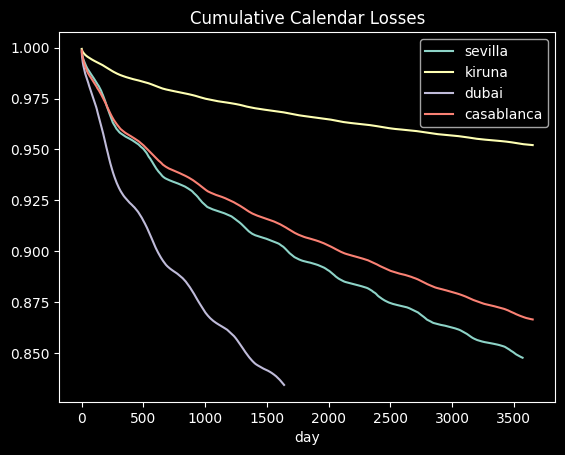

In [57]:
calendar_losses = pd.concat([results[city]['calendar_loss'] for city in results], axis=1)
calendar_losses.columns = list(results.keys())
(1 - calendar_losses.cumsum(axis=0)).plot(title='Cumulative Calendar Losses')

In [48]:
results['sevilla']['soh'].iloc[-1]

np.float64(0.7999494620080625)

<Axes: title={'center': 'Cumulative Cycle Losses'}, xlabel='day'>

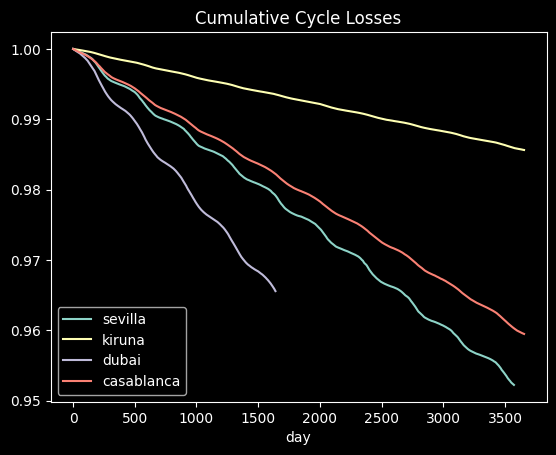

In [58]:
cycle_losses = pd.concat([results[city]['cycle_loss'] for city in results], axis=1)
cycle_losses.columns = list(results.keys())
(1 - cycle_losses.cumsum(axis=0)).plot(title='Cumulative Cycle Losses')


<Axes: title={'center': 'SOH'}, xlabel='day'>

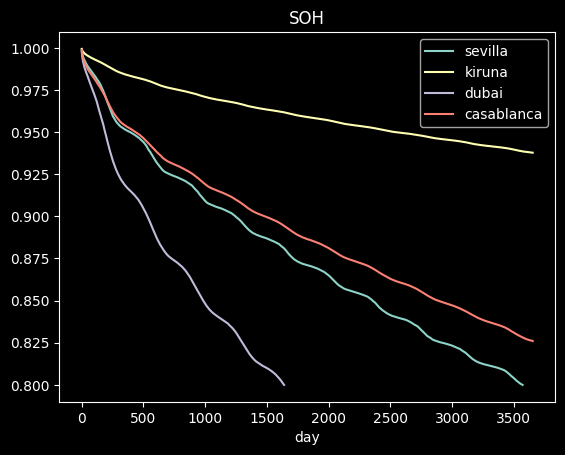

In [60]:
# YEY!!!
soh = pd.concat([results[city]['soh'] for city in results], axis=1)
soh.columns = list(results.keys())
soh.plot(title="SOH")